# Job Market Analytics Dashboard

## Exploratory Data Analysis (EDA)

Dataset: LinkedIn Job Postings

Author: Vinay

Goal:
Analyze job market trends, hiring companies, experience levels, locations, and salaries.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("../data/postings.csv")

In [5]:
df.head()

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


## Dataset Overview

In [6]:
print("Total Jobs:", len(df))
print("Total Companies:", df["company_name"].nunique())
print("Total Locations:", df["location"].nunique())
print("Total Job Titles:", df["title"].nunique())

Total Jobs: 123849
Total Companies: 24428
Total Locations: 8526
Total Job Titles: 72521


## Missing Values

In [8]:
missing = df.isnull().sum()

missing.sort_values(ascending=False).head(15)

closed_time                   122776
skills_desc                   121410
med_salary                    117569
remote_allowed                108603
applies                       100529
min_salary                     94056
max_salary                     94056
currency                       87776
compensation_type              87776
pay_period                     87776
normalized_salary              87776
posting_domain                 39968
application_url                36665
formatted_experience_level     29409
fips                           27415
dtype: int64

## Experience Level Distribution

In [9]:
df["formatted_experience_level"].value_counts()

formatted_experience_level
Mid-Senior level    41489
Entry level         36708
Associate            9826
Director             3746
Internship           1449
Executive            1222
Name: count, dtype: int64

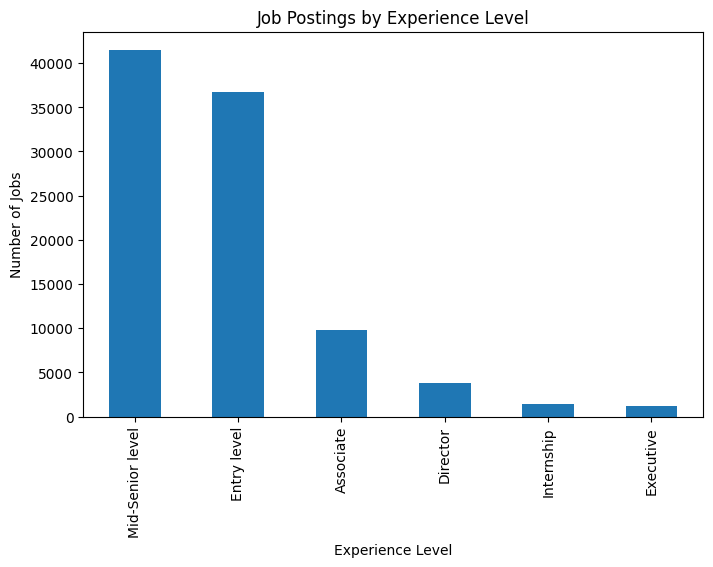

In [10]:
exp = df["formatted_experience_level"].value_counts()

plt.figure(figsize=(8,5))
exp.plot(kind="bar")

plt.title("Job Postings by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Number of Jobs")

plt.show()

## Key Insights

### Insight 1
Mid-Senior level positions represent the largest share of job postings.

### Insight 2
Entry-level opportunities account for more than 36,000 postings.

### Insight 3
Internship opportunities are relatively limited compared to full-time roles.

## Location Analysis

In [11]:
top_locations = df["location"].value_counts().head(10)

top_locations

location
United States    8125
New York, NY     2756
Chicago, IL      1834
Houston, TX      1762
Dallas, TX       1383
Atlanta, GA      1363
Boston, MA       1176
Austin, TX       1083
Charlotte, NC    1075
Phoenix, AZ      1059
Name: count, dtype: int64

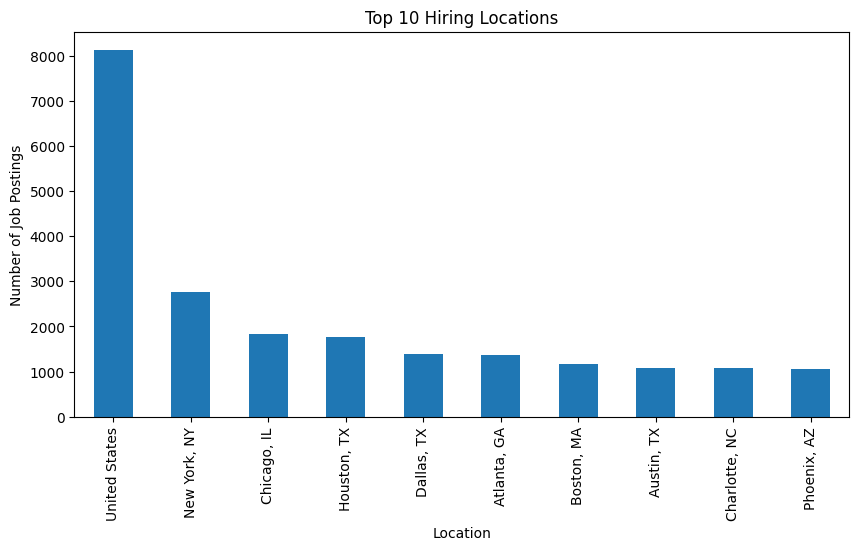

In [12]:
plt.figure(figsize=(10,5))

top_locations.plot(kind="bar")

plt.title("Top 10 Hiring Locations")
plt.xlabel("Location")
plt.ylabel("Number of Job Postings")

plt.show()

### Business Insight

The United States accounts for the largest share of job postings in the dataset. Among individual cities, New York leads hiring activity, followed by Chicago, Houston, and Dallas.

The concentration of opportunities in these metropolitan areas suggests that employment demand is strongly associated with major economic and business centers. These cities host large numbers of corporations, financial institutions, healthcare organizations, and technology companies, resulting in higher recruitment activity.

## Work Type Analysis

In [14]:
df["formatted_work_type"].value_counts()

formatted_work_type
Full-time     98814
Contract      12117
Part-time      9696
Temporary      1190
Internship      983
Volunteer       562
Other           487
Name: count, dtype: int64

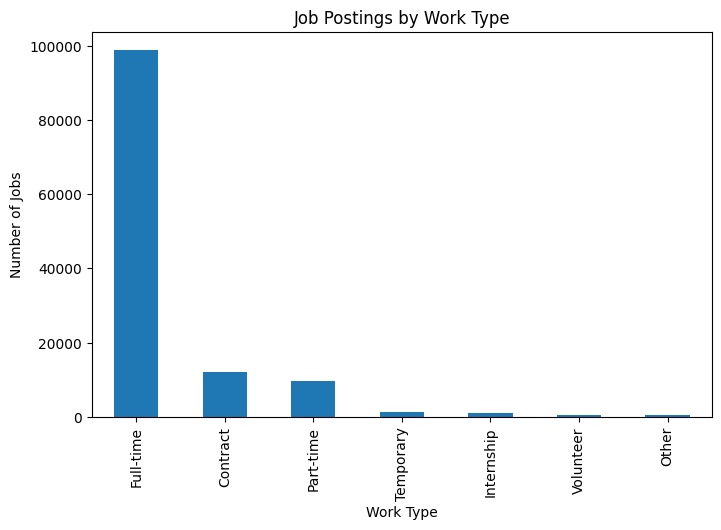

In [15]:
work_type = df["formatted_work_type"].value_counts()

plt.figure(figsize=(8,5))
work_type.plot(kind="bar")

plt.title("Job Postings by Work Type")
plt.xlabel("Work Type")
plt.ylabel("Number of Jobs")

plt.show()

### Business Insight

Full-time positions overwhelmingly dominate the job market, accounting for the vast majority of job postings in the dataset. Contract and part-time opportunities exist but represent a much smaller share of the market.

Internship opportunities are relatively limited compared to permanent employment opportunities, indicating that employers primarily focus on recruiting long-term employees rather than short-term interns or temporary workers.

### Why It Matters

For job seekers, the data suggests that focusing on full-time opportunities will provide access to the largest portion of the job market.

Students and recent graduates may face stronger competition for internships due to their limited availability, making entry-level full-time positions an important alternative career path.

## Salary Analysis

In [16]:
salary_df = df["normalized_salary"].dropna()

salary_df.describe()

count    3.607300e+04
mean     2.053270e+05
std      5.097627e+06
min      0.000000e+00
25%      5.200000e+04
50%      8.150000e+04
75%      1.250000e+05
max      5.356000e+08
Name: normalized_salary, dtype: float64

### Business Insight

Salary data is available for approximately 36,000 job postings. The median salary is approximately $81,500, meaning half of the reported salaries fall below this value and half above it.

The average salary is significantly higher at approximately $205,000. This large gap between the mean and median suggests that a small number of extremely high-paying jobs are pulling the average upward, resulting in a highly skewed salary distribution.

### Why It Matters

Job seekers should not rely solely on average salary figures when evaluating market compensation. The median salary provides a more realistic representation of typical earnings because it is less affected by extreme outliers.

Organizations and analysts often use median compensation when assessing salary benchmarks for the broader workforce.

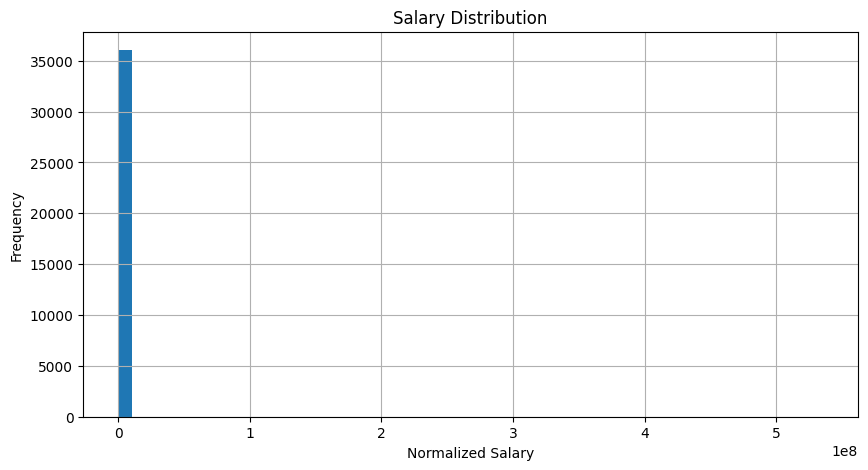

In [17]:
plt.figure(figsize=(10,5))

salary_df.hist(bins=50)

plt.title("Salary Distribution")
plt.xlabel("Normalized Salary")
plt.ylabel("Frequency")

plt.show()

### Business Insight

The salary distribution is heavily right-skewed. Most job postings are concentrated within a relatively small salary range, while a small number of extremely high salary values extend far beyond the typical compensation levels.

These extreme values significantly affect the distribution and may represent data-entry errors, unusual executive compensation packages, or inconsistencies in salary reporting.

### Why It Matters

Outliers can distort statistical measures such as the mean and make visualizations difficult to interpret. Before conducting salary analysis, it is important to identify and handle extreme values to ensure that insights accurately reflect the broader job market.

## Salary Outlier Detection

In [18]:
salary_df = df["normalized_salary"].dropna()

print("95th Percentile:", salary_df.quantile(0.95))
print("99th Percentile:", salary_df.quantile(0.99))

95th Percentile: 200000.0
99th Percentile: 300807.9999999987


In [19]:
salary_df = df["normalized_salary"].dropna()

print("95th Percentile:", salary_df.quantile(0.95))
print("99th Percentile:", salary_df.quantile(0.99))

95th Percentile: 200000.0
99th Percentile: 300807.9999999987


## Salary Analysis After Outlier Removal

In [20]:
clean_salary = salary_df[salary_df <= salary_df.quantile(0.99)]

print(clean_salary.describe())

count     35712.000000
mean      92531.378605
std       51872.627256
min           0.000000
25%       51480.000000
50%       80080.000000
75%      123216.600000
max      300500.000000
Name: normalized_salary, dtype: float64


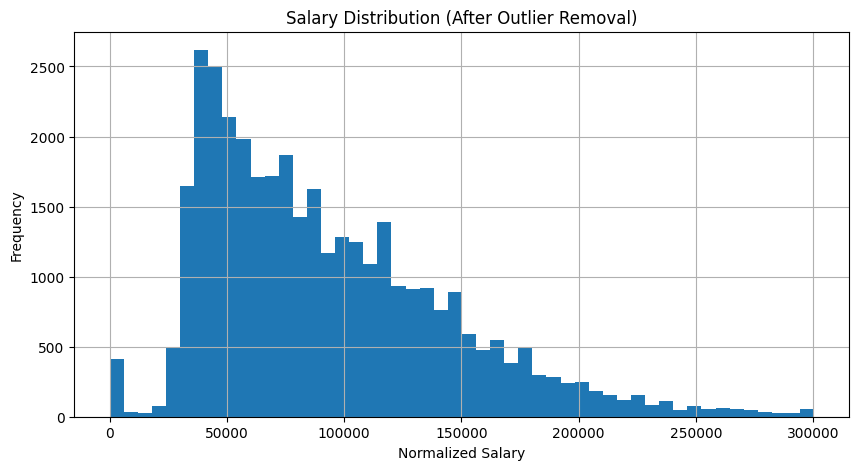

In [21]:
plt.figure(figsize=(10,5))

clean_salary.hist(bins=50)

plt.title("Salary Distribution (After Outlier Removal)")
plt.xlabel("Normalized Salary")
plt.ylabel("Frequency")

plt.show()

### Business Insight

After removing salaries above the 99th percentile, the salary distribution becomes significantly more interpretable.

Most job postings fall within the $40,000 to $120,000 salary range, with the highest concentration around $40,000–$80,000. As salaries increase, the number of available jobs gradually decreases, indicating that high-paying opportunities are less common than mid-range positions.

The distribution remains right-skewed, meaning a smaller number of jobs offer substantially higher compensation than the majority of positions.

### Why It Matters

This analysis provides a more realistic view of the job market by reducing the influence of extreme salary outliers.

For job seekers, the results indicate that most opportunities are concentrated in mid-range salary bands, while highly compensated positions represent a smaller portion of the market and are likely associated with specialized skills or senior-level experience.

# Key Findings So Far

1. The dataset contains 123,849 job postings from 24,428 companies.

2. Mid-Senior level positions represent the largest share of postings, although more than 36,000 entry-level opportunities exist.

3. Hiring activity is concentrated in major metropolitan areas such as New York, Chicago, Houston, and Dallas.

4. Full-time employment dominates the job market, while internships represent a relatively small portion of postings.

5. Salary data contains significant outliers. After removing extreme values, most jobs fall within the $40,000–$120,000 salary range.

# Data Cleaning

In [22]:
important_columns = [
    "company_name",
    "title",
    "location",
    "formatted_work_type",
    "formatted_experience_level",
    "normalized_salary",
    "views",
    "applies"
]

clean_df = df[important_columns]

clean_df.head()

,company_name,title,location,formatted_work_type,formatted_experience_level,normalized_salary,views,applies
0,Corcoran Sawyer Smith,Marketing Coordinator,"Princeton, NJ",Full-time,NaN,38480.0,20.0,2.0
1,NaN,Mental Health Therapist/Counselor,"Fort Collins, CO",Full-time,NaN,83200.0,1.0,NaN
2,The National Exemplar,Assitant Restaurant Manager,"Cincinnati, OH",Full-time,NaN,55000.0,8.0,NaN
3,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,"New Hyde Park, NY",Full-time,NaN,157500.0,16.0,NaN
4,NaN,Service Technician,"Burlington, IA",Full-time,NaN,70000.0,3.0,NaN


### Business Insight

The dataset originally contained 31 columns, many of which were related to URLs, geographic identifiers, or metadata that were not relevant to the analytical objectives of the project.

To improve clarity and efficiency, only columns directly related to job characteristics, company information, location, work type, experience level, salary, and engagement metrics were retained.

In [23]:
clean_df.isnull().sum()

company_name                    1719
title                              0
location                           0
formatted_work_type                0
formatted_experience_level     29409
normalized_salary              87776
views                           1689
applies                       100529
dtype: int64

### Business Insight

The dataset contains missing values across several key variables. Salary information is unavailable for a significant portion of job postings, while application counts are missing for the majority of records.

Experience level information is also incomplete, though enough data remains to support meaningful analysis. Company names and view counts have relatively low levels of missingness and can be retained with minimal impact on analysis quality.

### Why It Matters

Missing values can influence analytical results and dashboard accuracy. Understanding the extent of missing data helps determine which variables can be used reliably and which require special handling during data preparation.

In [24]:
clean_df["company_name"] = clean_df["company_name"].fillna("Unknown")

clean_df["formatted_experience_level"] = (
    clean_df["formatted_experience_level"]
    .fillna("Not Specified")
)

clean_df["views"] = clean_df["views"].fillna(0)

clean_df["applies"] = clean_df["applies"].fillna(0)

C:\Users\vinay\AppData\Local\Temp\ipykernel_22332\394609690.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df["company_name"] = clean_df["company_name"].fillna("Unknown")
C:\Users\vinay\AppData\Local\Temp\ipykernel_22332\394609690.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df["formatted_experience_level"] = (
C:\Users\vinay\AppData\Local\Temp\ipykernel_22332\394609690.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[ro

In [25]:
clean_df.isnull().sum()

company_name                      0
title                             0
location                          0
formatted_work_type               0
formatted_experience_level        0
normalized_salary             87776
views                             0
applies                           0
dtype: int64

### Business Insight

After cleaning, all critical categorical and engagement-related fields contain complete information. Salary remains unavailable for a large portion of postings, which reflects employer reporting practices rather than missing data errors.

Retaining missing salary values preserves data integrity and ensures that future salary analyses are based only on jobs with reported compensation.

In [26]:
clean_df.to_csv("../data/cleaned_postings.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
